# MNIST DCGAN with Keras 3 — PyTorch Backend

This complete workflow modernizes the archived DCGAN. A fixed 100-dimensional noise panel
tracks the same generated samples across training. Full execution uses 50
epochs and batch size 128. Reduce `EPOCHS` to 1 or 2 for a quicker run.

Losses and selected images are diagnostics, not proof that the generator
learned the complete data distribution.

## Runtime dependency check

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path

REQUIRED_RUNTIME = {'keras': 'keras', 'torch': 'torch'}
COLAB_EXTRAS = {}
missing_required = [
    package for module, package in REQUIRED_RUNTIME.items()
    if importlib.util.find_spec(module) is None
]
missing_extras = [
    package for module, package in COLAB_EXTRAS.items()
    if importlib.util.find_spec(module) is None
]
if missing_extras and "google.colab" in sys.modules:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_extras]
    )
    missing_extras = []
if missing_required or missing_extras:
    missing = ", ".join(missing_required + missing_extras)
    raise RuntimeError(
        f"Missing notebook dependencies: {missing}. Locally run "
        "`uv sync --group notebooks`; in Colab restart the runtime if an "
        "installation cell just changed the environment."
    )
print("runtime dependency check passed")

runtime dependency check passed


In [2]:
%matplotlib inline

## Keras-to-PyTorch crosswalk

This optional implementation uses the same Torch runtime as the canonical
native PyTorch path. Keras `compile()` selects the optimizer and loss,
`fit()` owns the explicit batch and epoch loop, and callbacks provide
high-level training control. Data, splits, budgets, evidence, and scientific
conclusions remain aligned with the canonical PyTorch workflow.

## Imports, data, and fixed seeds

In [3]:
import hashlib
import json
import os

os.environ["KERAS_BACKEND"] = "torch"

import keras
import matplotlib.pyplot as plt
import numpy as np
import torch
from keras import layers
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split

assert keras.backend.backend() == "torch"
print(
    f"Keras {keras.__version__}; backend={keras.backend.backend()}; "
    f"PyTorch {torch.__version__}"
)

SEED = 42
EPOCHS = 50  # Reduce to 1 or 2 for a quicker run.
BATCH_SIZE = 128
LATENT_DIM = 100
LABEL_SMOOTHING = 0.0
keras.utils.set_random_seed(SEED)
(x_train, _), _ = keras.datasets.mnist.load_data()
x_train = (x_train.astype("float32") - 127.5) / 127.5
x_train = x_train[..., np.newaxis]
dataset = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(x_train)),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    generator=torch.Generator().manual_seed(SEED),
)
fixed_noise = keras.random.normal((16, LATENT_DIM), seed=SEED)

Keras 3.15.1; backend=torch; PyTorch 2.13.0


## Define generator and discriminator

In [4]:
generator = keras.Sequential(
    [
        keras.Input(shape=(LATENT_DIM,)),
        layers.Dense(7 * 7 * 256, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Reshape((7, 7, 256)),
        layers.Conv2DTranspose(128, 5, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Conv2DTranspose(64, 5, strides=2, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Conv2DTranspose(1, 5, strides=2, padding="same", activation="tanh"),
    ],
    name="generator",
)
discriminator = keras.Sequential(
    [
        keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(64, 5, strides=2, padding="same"),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.3),
        layers.Conv2D(128, 5, strides=2, padding="same"),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1),
    ],
    name="discriminator",
)
class AdversarialModel(keras.Model):
    def __init__(self, generator, discriminator, latent_dim, label_smoothing):
        super().__init__()
        self.generator = generator
        self.discriminator = discriminator
        self.latent_dim = latent_dim
        self.label_smoothing = label_smoothing
        self.seed_generator = keras.random.SeedGenerator(SEED)
        self.generator_loss_tracker = keras.metrics.Mean(name="generator_loss")
        self.discriminator_loss_tracker = keras.metrics.Mean(name="discriminator_loss")
        self.built = True

    @property
    def metrics(self):
        return [self.generator_loss_tracker, self.discriminator_loss_tracker]

    def compile(self, generator_optimizer, discriminator_optimizer, loss_function):
        super().compile()
        self.generator_optimizer = generator_optimizer
        self.discriminator_optimizer = discriminator_optimizer
        self.loss_function = loss_function

    def train_step(self, real_images):
        if isinstance(real_images, (tuple, list)):
            real_images = real_images[0]
        batch_size = real_images.shape[0]

        noise = keras.random.normal(
            (batch_size, self.latent_dim), seed=self.seed_generator
        )
        generated_images = self.generator(noise, training=True)

        self.zero_grad()
        real_logits = self.discriminator(real_images, training=True)
        generated_logits = self.discriminator(generated_images.detach(), training=True)
        real_targets = torch.ones_like(real_logits) * (1.0 - self.label_smoothing)
        discriminator_loss = self.loss_function(real_targets, real_logits) + self.loss_function(
            torch.zeros_like(generated_logits), generated_logits
        )
        discriminator_loss.backward()
        discriminator_weights = list(self.discriminator.trainable_weights)
        discriminator_gradients = [weight.value.grad for weight in discriminator_weights]
        with torch.no_grad():
            self.discriminator_optimizer.apply(
                discriminator_gradients, discriminator_weights
            )

        noise = keras.random.normal(
            (batch_size, self.latent_dim), seed=self.seed_generator
        )
        self.zero_grad()
        generated_logits = self.discriminator(
            self.generator(noise, training=True), training=True
        )
        generator_loss = self.loss_function(
            torch.ones_like(generated_logits), generated_logits
        )
        generator_loss.backward()
        generator_weights = list(self.generator.trainable_weights)
        generator_gradients = [weight.value.grad for weight in generator_weights]
        with torch.no_grad():
            self.generator_optimizer.apply(generator_gradients, generator_weights)

        self.generator_loss_tracker.update_state(generator_loss)
        self.discriminator_loss_tracker.update_state(discriminator_loss)
        return {
            "generator_loss": self.generator_loss_tracker.result(),
            "discriminator_loss": self.discriminator_loss_tracker.result(),
        }


gan = AdversarialModel(generator, discriminator, LATENT_DIM, LABEL_SMOOTHING)
gan.compile(
    generator_optimizer=keras.optimizers.Adam(1e-4),
    discriminator_optimizer=keras.optimizers.Adam(1e-4),
    loss_function=keras.losses.BinaryCrossentropy(from_logits=True),
)

## Train adversarially through the high-level fit workflow

In [5]:
history = gan.fit(dataset, epochs=EPOCHS, verbose=2, shuffle=False)
generator_losses = [float(value) for value in history.history["generator_loss"]]
discriminator_losses = [
    float(value) for value in history.history["discriminator_loss"]
]

Epoch 1/50


468/468 - 45s - 96ms/step - discriminator_loss: 0.9501 - generator_loss: 1.1166


Epoch 2/50


468/468 - 45s - 97ms/step - discriminator_loss: 1.1429 - generator_loss: 1.1004


Epoch 3/50


...

468/468 - 50s - 106ms/step - discriminator_loss: 1.2489 - generator_loss: 0.8945


Epoch 49/50


468/468 - 49s - 105ms/step - discriminator_loss: 1.2560 - generator_loss: 0.9010


Epoch 50/50


468/468 - 49s - 105ms/step - discriminator_loss: 1.2482 - generator_loss: 0.9313


## Fixed-noise evidence

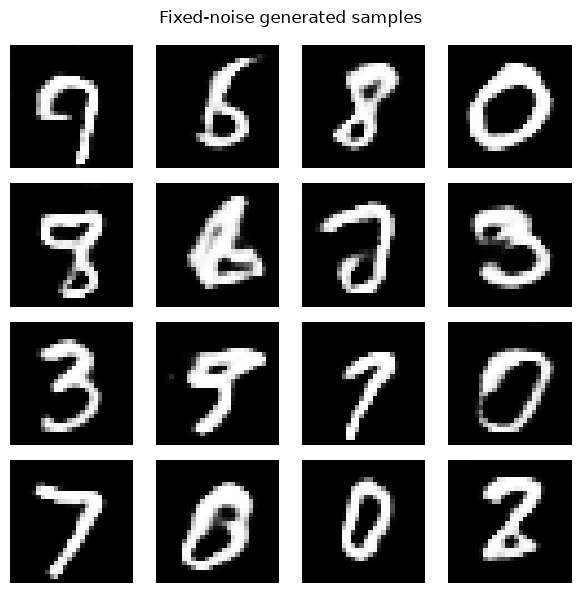

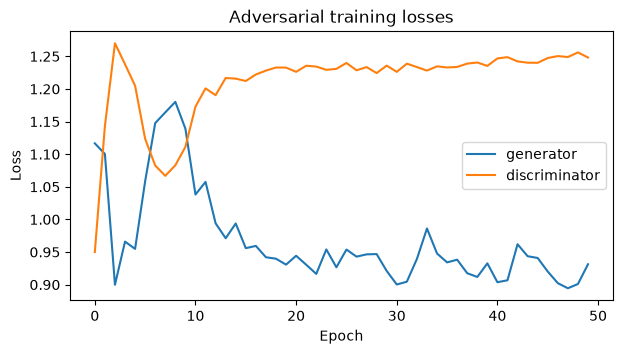

mean per-pixel sample standard deviation: 0.3466
HELIO_RESULT {"discriminator_loss": 1.2481979131698608, "epochs": 50, "generated_shape": [16, 28, 28, 1], "generator_loss": 0.931276798248291, "pixel_diversity": 0.34664812684059143}


In [6]:
generated = generator(fixed_noise, training=False).detach().cpu().numpy()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for axis, image in zip(axes.flat, generated):
    axis.imshow(image.squeeze(), cmap="gray", vmin=-1, vmax=1)
    axis.axis("off")
plt.suptitle("Fixed-noise generated samples")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(generator_losses, label="generator")
ax.plot(discriminator_losses, label="discriminator")
ax.set(title="Adversarial training losses", xlabel="Epoch", ylabel="Loss")
ax.legend()
plt.show()

pixel_diversity = float(generated.std(axis=0).mean())
print(f"mean per-pixel sample standard deviation: {pixel_diversity:.4f}")
print(
    "HELIO_RESULT "
    + json.dumps(
        {
            "epochs": EPOCHS,
            "generated_shape": list(generated.shape),
            "generator_loss": generator_losses[-1],
            "discriminator_loss": discriminator_losses[-1],
            "pixel_diversity": pixel_diversity,
        },
        sort_keys=True,
    )
)
assert generated.shape == (16, 28, 28, 1)
assert np.isfinite(generated).all()
assert pixel_diversity > 0

## Try it yourself in Keras

Change one choice at a time and keep the data split and evaluation unchanged:

- try discriminator label smoothing of `0.1`.
- vary the latent dimension while keeping the fixed noise samples.
- save the fixed-noise grid at several points during training.